In [1]:
# Imports n' Shit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from idun_guardian_sdk import GuardianClient, FileTypes
from scipy import signal
import ipympl

df = pd.read_csv("../data/eeg_Test3Simon.csv")


In [2]:
# Daten schnell anschauen
print(df.head())
fs = 250  # Sampling Rate in Hz

      timestamp           ch1
0  1.776150e+09 -28147.484737
1  1.776150e+09 -28140.712159
2  1.776150e+09 -28153.653819
3  1.776150e+09 -28152.312714
4  1.776150e+09 -28170.596441


In [3]:
# Zeit relativ zum Start in Sekunden berechnen
df['time_sec'] = (df['timestamp'] - df['timestamp'].iloc[0])

# Sampling Rate definieren
fs = 250

# 1. Sicherstellen, dass alles Zahlen sind & NaNs löschen
df['ch1'] = pd.to_numeric(df['ch1'], errors='coerce')
df = df.dropna(subset=['ch1']).copy()

# 2. Zeitachse für den gesamten Zeitraum
df['time_sec'] = (df['timestamp'] - df['timestamp'].iloc[0])

# 3. Filter auf alles anwenden (1-30 Hz)
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, data)

df['ch1_filtered'] = bandpass_filter(df['ch1'].values, 1.0, 30.0, fs=250)

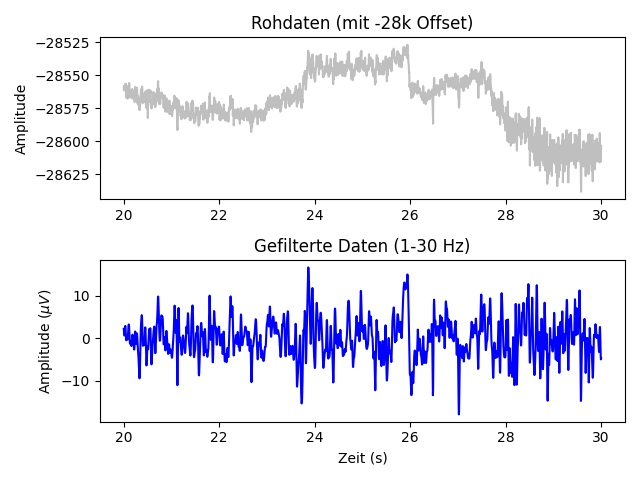

In [4]:
# Wir schauen uns 10 Sekunden an (z.B. von Sekunde 20 bis 30)
start, end = 20, 30
mask = (df['time_sec'] >= start) & (df['time_sec'] <= end)
subset = df[mask]

plt.figure()

# Subplot 1: Rohdaten (man sieht den Offset)
plt.subplot(2, 1, 1)
plt.plot(subset['time_sec'], subset['ch1'], color='gray', alpha=0.5)
plt.title("Rohdaten (mit -28k Offset)")
plt.ylabel("Amplitude")

# Subplot 2: Gefilterte Daten
plt.subplot(2, 1, 2)
plt.plot(subset['time_sec'], subset['ch1_filtered'], color='blue')
plt.title("Gefilterte Daten (1-30 Hz)")
plt.ylabel("Amplitude ($\mu V$)")
plt.xlabel("Zeit (s)")

plt.tight_layout()
plt.show()

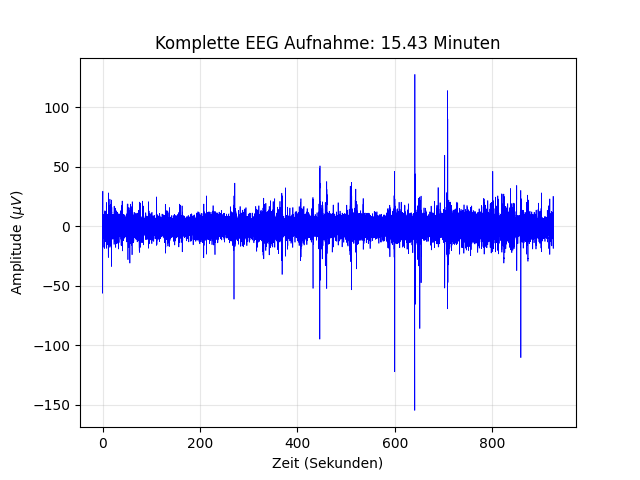

In [5]:
plt.figure()

# Plot der gefilterten Daten
plt.plot(df['time_sec'], df['ch1_filtered'], color='blue', linewidth=0.5)

plt.title(f"Komplette EEG Aufnahme: {df['time_sec'].max() / 60:.2f} Minuten")
plt.xlabel("Zeit (Sekunden)")
plt.ylabel("Amplitude ($\mu V$)")
plt.grid(True, alpha=0.3)

# Optional: Setze das Limit der Y-Achse, falls Artefakte (z.B. Kopfbewegungen) 
# den Plot skalieren. Meistens reichen -100 bis 100 µV für sauberes EEG.
# plt.ylim(-150, 150) 

plt.show()

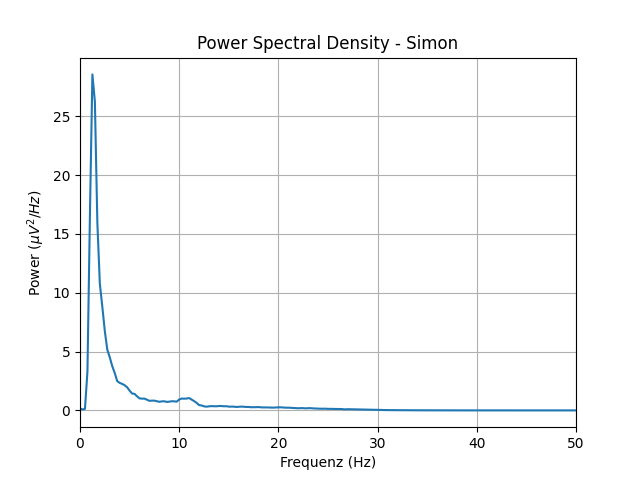

In [25]:
# .values stellt sicher, dass Scipy nur die reinen Zahlen bekommt
f, psd = signal.welch(df['ch1_filtered'].values, fs, nperseg=fs*4)

plt.figure()
plt.plot(f, psd)
plt.xlim(0, 50) 
plt.title("Power Spectral Density - Simon")
plt.xlabel("Frequenz (Hz)")
plt.ylabel("Power ($\mu V^2/Hz$)")
plt.grid(True)
plt.show()